In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.ndimage import map_coordinates
from tqdm import tqdm

In [3]:
img = np.fromfile('volume.bin', dtype=np.uint16).reshape((512, 290, 512))
head = pv.read('source_vtps/head.vtp')
res = (512, 290, 512)
dim = np.array((0.78125, 1, 0.78125))

In [4]:
a, b, c, d = 49.5, -411.25, -1155, 148583.5
da, db, dc = a/d, b/d, c/d
norm_factor = np.sqrt(da**2 + db**2 + dc**2)
da, db, dc = da/norm_factor, db/norm_factor, dc/norm_factor
print(da, db, dc)
print(np.arctan(da / dc) * 180 / np.pi, np.arctan(db / dc) * 180 / np.pi)

vector_length = 200
vector_center = (-3, 52, 110)
vector_end = (vector_center[0] + da * vector_length, vector_center[1] + db * vector_length, vector_center[2] + dc * vector_length)
print(vector_end)
uv_green = np.array((0, -33, 11.75))
uv_red = np.array((-35, 0, -1.5))
uv_green = uv_green / np.linalg.norm(uv_green)
uv_red = uv_red / np.linalg.norm(uv_red)
uv_blue = np.array([da, db, dc])
uv_blue = -uv_blue / np.linalg.norm(uv_blue)
print(uv_green, uv_red, uv_blue)

# ax + by + cz + d = 0
def calculate_x(y, z):
    return (d - b * y - c * z) / a

def calculate_y(x, z):
    return (d - a * x - c * z) / b

def calculate_z(x, y):
    return (d - a * x - b * y) / c

def point_plus_vector(point, vector):
    return (point[0] + vector[0], point[1] + vector[1], point[2] + vector[2])

r = (35.02945189408479 + 35.03212811120672) / 2

0.04034132277855472 -0.33515896954910357 -0.9412975314996102
-2.454031674527075 19.598811324586006
(np.float64(5.068264555710943), np.float64(-15.03179390982072), np.float64(-78.25950629992204))
[ 0.         -0.94206441  0.33543203] [-0.9990829   0.         -0.04281784] [-0.04034132  0.33515897  0.94129753]


In [73]:
def point(x, y, z):
    #return pv.Sphere(center = (x * dim[0], y * dim[1], z * dim[2]), radius = 10)
    return pv.Sphere(center = (x, y, z), radius = 2)

plotter = pv.Plotter()
plotter.add_mesh(head, color = 'gray', opacity = 0.25)
plotter.add_mesh(point(-3, 52, 110), color = 'blue') # Center
plotter.add_mesh(point(-3, 85, 98.25), color = 'green')
print(np.sqrt((52-85)**2 + (110-98.25)**2))
plotter.add_mesh(point(-3, 19, 121.75), color = 'green')
print(np.sqrt((52-19)**2 + (110-121.75)**2))
plotter.add_mesh(point(-38, 52, 108.5), color = 'red')
print(np.sqrt((-38+3)**2 + (110-108.5)**2))
plotter.add_mesh(point(32, 52, 111.5), color = 'red')
print(np.sqrt((32+3)**2 + (110-111.5)**2))

line = pv.Line(vector_center, vector_end)
plotter.add_mesh(line, color = 'blue', line_width = 5)
plotter.add_mesh(point(*point_plus_vector(vector_center, r * uv_green + r * uv_red)), color = 'orange')
plotter.add_mesh(point(*point_plus_vector(vector_center, r * uv_green - r * uv_red)), color = 'orange')
plotter.add_mesh(point(*point_plus_vector(vector_center, -r * uv_green + r * uv_red)), color = 'orange')
plotter.add_mesh(point(*point_plus_vector(vector_center, -r * uv_green - r * uv_red)), color = 'orange')

mesh = pv.ImageData(dimensions = res + np.array([1, 1, 1]))
mesh.spacing = dim
#mesh.origin = (-res[0] * dim[0] / 2, -res[1] * dim[1] / 2, -res[2] * dim[2] / 2)
mesh.cell_data["density"] = img.ravel(order = "F")
mesh = mesh.threshold(950, scalars = "density")
surface = mesh.extract_surface()
#plotter.add_mesh(surface, color = 'red', opacity = 0.4)

#plotter.add_mesh(point(100, 100, 100), color = 'blue')
#for i in range(20):
#    plotter.add_mesh(point(*(vector_center + 10 * uv_blue * i)), color = 'blue')
plotter.export_html('test.html')
plotter.show()

35.02945189408479
35.02945189408479
35.03212811120672
35.03212811120672


Widget(value='<iframe src="http://localhost:39423/index.html?ui=P_0x7b15f18fbc20_5&reconnect=auto" class="pyvi…

(512, 290, 512)
[252.16 197.   396.8 ] 1046.72
[252.13418155 197.16757948 397.40243042] 1047.6897
[252.10836311 197.33515897 398.00486084] 1037.8396
[252.08254466 197.50273845 398.60729126] 1030.0099
[252.05672621 197.67031794 399.20972168] 1026.3096
[252.03090777 197.83789742 399.8121521 ] 1027.556
[252.00508932 198.00547691 400.41458252] 1029.7345
[251.97927087 198.17305639 401.01701294] 1030.8103
[251.95345243 198.34063588 401.61944336] 1031.0017
[251.92763398 198.50821536 402.22187378] 1033.0483
[251.90181553 198.67579485 402.8243042 ] 1037.1473
[251.87599709 198.84337433 403.42673462] 1039.0624
[251.85017864 199.01095382 404.02916504] 1038.9601
[251.82436019 199.1785333  404.63159546] 1039.6749
[251.79854175 199.34611279 405.23402588] 1039.7147
[251.7727233  199.51369227 405.8364563 ] 1038.3011
[251.74690485 199.68127176 406.43888672] 1040.2262
[251.72108641 199.84885124 407.04131714] 1042.3616
[251.69526796 200.01643073 407.64374756] 1046.7075
[251.66944952 200.18401021 408.24617

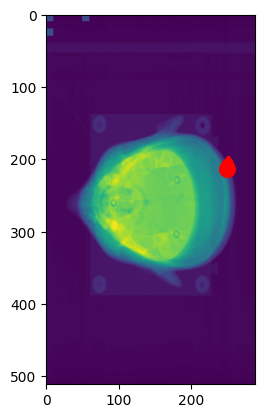

In [ ]:
def reorder(vector):
    #return np.array([vector[1], vector[0], vector[2]])
    return vector

img_copy = img.copy().astype(np.float32)
print(img_copy.shape)
#img_copy = np.flip(img_copy, axis = 0)
#
#img_copy = np.flip(img_copy, axis = 1)
img_copy[0:10,0:10,0:10] = 10000

img_copy[20:30,0:10,0:10] = 10000
img_copy[0:10,50:60,0:10] = 10000
#img_copy = img_copy[:,:,:200]
#img_copy[252, 197, 396] = 4999999
plt.imshow(img_copy.sum(axis = 2))

offset = (res[0] / 2, res[1] / 2, res[2] / 2)

def intensity(pixel_vector):
    pixel_vector = np.array([pixel_vector]).T
    return map_coordinates(img_copy, pixel_vector, order = 1, mode = 'nearest')[0]
    
def intensity_rounded(pixel_vector):
    #print(round(pixel_vector[0]), round(pixel_vector[1]), round(pixel_vector[2]))
    return img_copy[round(pixel_vector[0]), round(pixel_vector[1]), round(pixel_vector[2])]

for i in range(100):
    pixel_vector = (vector_center + 0.5 * uv_blue * i) / dim + offset
    plt.plot(reorder(pixel_vector)[0], reorder(pixel_vector)[1], 'ro', markersize = 1 + i*0.1)
    print(reorder(pixel_vector), intensity(reorder(pixel_vector)))
plt.show()

In [15]:
plane_origin = vector_center
plane_min = vector_center - r * uv_green - r * uv_red
print(plane_min)

dim_xy = 140
dim_z = 128

total_xy_length = 2*r
increment = total_xy_length / dim_xy
img_copy = img_copy.astype(np.float32)
print(img_copy.shape, img_copy[0:5, 0:5, 0:5])
def intensity(pixel_vector):
    pixel_vector = np.array([pixel_vector]).T
    return map_coordinates(img_copy, pixel_vector, order = 1, mode = 'nearest')[0]

print(vector_center, np.array([vector_center]).T)
print(intensity(np.array([vector_center]).T))
for i in range(40):
    pixel_vector = (vector_center + 1 * uv_blue * i) / dim + offset
    print(pixel_vector[2])
    print(intensity(reorder(np.array([vector_center + 5 * uv_blue * i]).T)))




            

[31.99866312 85.00126058 99.74949386]
(512, 290, 512) [[[10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]]

 [[10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]]

 [[10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]]

 [[10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]]

 [[10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  [10000. 10000. 10000. 10000. 10000.]
  

RuntimeError: invalid shape for coordinate array

In [ ]:
print(img_copy[252, 197,396])

In [16]:
intensity_map = np.zeros((dim_xy, dim_xy, 400))

for i in tqdm(range(dim_xy)):
    coord = plane_min + increment * uv_red * i
    for j in range(dim_xy):
        coord += increment * uv_green
        for k in range(400):
            vector_coord = (coord + 0.1 * uv_blue * k) / dim + offset
            vector_coord = reorder(vector_coord)
            intensity_map[i, j, k] = intensity(vector_coord)

print(intensity_map[0:3, 0:3, 0:3])

100%|██████████| 140/140 [00:48<00:00,  2.86it/s]

[[[1260.5814209  1297.26647949 1357.67126465]
  [1127.36108398 1176.21362305 1226.49780273]
  [1122.05859375 1146.90087891 1173.54870605]]

 [[1184.44104004 1206.10009766 1250.97973633]
  [1093.57666016 1125.58337402 1159.56347656]
  [1092.81176758 1107.01989746 1122.29577637]]

 [[1130.27880859 1142.9765625  1171.00036621]
  [1074.61608887 1093.37145996 1114.29907227]
  [1074.67333984 1081.54443359 1088.99365234]]]


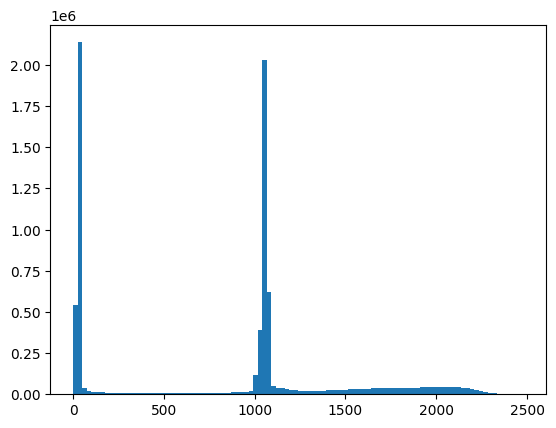

In [17]:
intensity_map.tofile('intensity_map.bin')
plt.hist(intensity_map.flatten(), bins = 100)
plt.show()

In [ ]:
fig = plt.figure()
plt.add_subplot(111, projection = '3d')
plt.plot_surface(intensity_map)
plt.show()

91 88
[np.int64(160), np.int64(212), np.int64(277)]


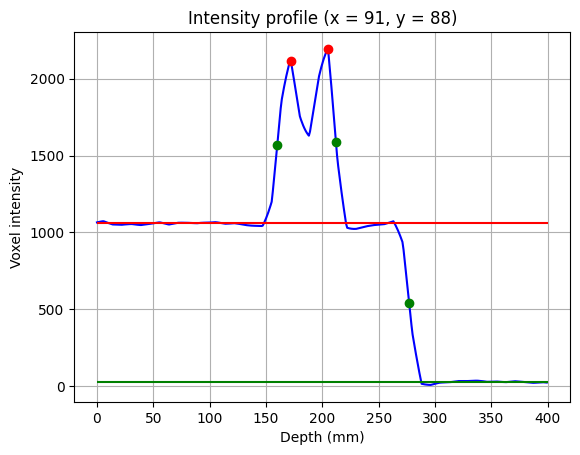

In [100]:
import random
from scipy.signal import find_peaks

dr = 1
prom = 50

def get_depth_points(x, y):
    points = []
    vertical_slice = intensity_map[x, y,:]
    peaks, _ = find_peaks(vertical_slice, prominence = prom)
    if len(peaks) < 2:
        return points
    peak1 = vertical_slice[peaks[0]]
    peak2 = vertical_slice[peaks[1]]
    # Find index in vertical_slice where vertical_slice is closest to a value (e.g., 1063), with index < peaks[0]
    value1 = (1063 + peak1) / 2
    value2 = (1063 + peak2) / 2
    valid_indices1  = np.arange(0, peaks[0])
    valid_indices2 = np.arange(peaks[1], len(vertical_slice))
    if len(valid_indices1) > 0:
        closest_idx1 = valid_indices1[np.argmin(np.abs(vertical_slice[valid_indices1] - value1))]
        closest_idx2 = valid_indices2[np.argmin(np.abs(vertical_slice[valid_indices2] - value2))]
        points.append(closest_idx1)
        points.append(closest_idx2)
    value3 = (1063 + 28) / 2
    valid_indices3 = np.arange(peaks[1], len(vertical_slice))
    if len(valid_indices3) > 0:
        closest_idx3 = valid_indices3[np.argmin(np.abs(vertical_slice[valid_indices3] - value3))]
        points.append(closest_idx3)
    return points
            

def smooth(arr):
    return np.convolve(arr, np.ones(5)/5, mode = 'valid')

x, y = random.randint(0, dim_xy-1), random.randint(0, dim_xy-1)
vertical_slice = intensity_map[x, y,:]
peaks, _ = find_peaks(vertical_slice, prominence = prom)
vertical_slice_gradient = np.gradient(vertical_slice)
peaksg, _ = find_peaks(vertical_slice_gradient, prominence = 10)
peaksgneg, _ = find_peaks(-vertical_slice_gradient, prominence = 10)
points = get_depth_points(x, y)
print(x, y)
print(points)
plt.figure(0)
plt.plot(vertical_slice, color = 'blue')
plt.plot(peaks, vertical_slice[peaks], 'ro')
plt.hlines(1063, 0, 400, color = 'red')
plt.hlines(28, 0, 400, color = 'green')
plt.plot(points, vertical_slice[points], 'go')
plt.grid()
plt.ylabel('Voxel intensity')
plt.xlabel('Depth (mm)')
plt.title('Intensity profile (x = {}, y = {})'.format(x, y))
plt.show()


In [26]:
x_coords = []
y_coords = []
inner_bone_value = []
outer_bone_value = []
head_value = []
for i in tqdm(range(dim_xy)):
    for j in range(dim_xy):
        vertical_slice = intensity_map[i, j, :]
        z = get_depth_points(i, j)
        if len(z) == 3:
            x_coords.append(i)
            y_coords.append(j)
            inner_bone_value.append(z[0])
            outer_bone_value.append(z[1])
            head_value.append(z[2])

print(len(x_coords), len(y_coords), len(inner_bone_value), len(outer_bone_value), len(head_value))


100%|██████████| 140/140 [00:00<00:00, 323.72it/s]

19253 19253 19253 19253 19253


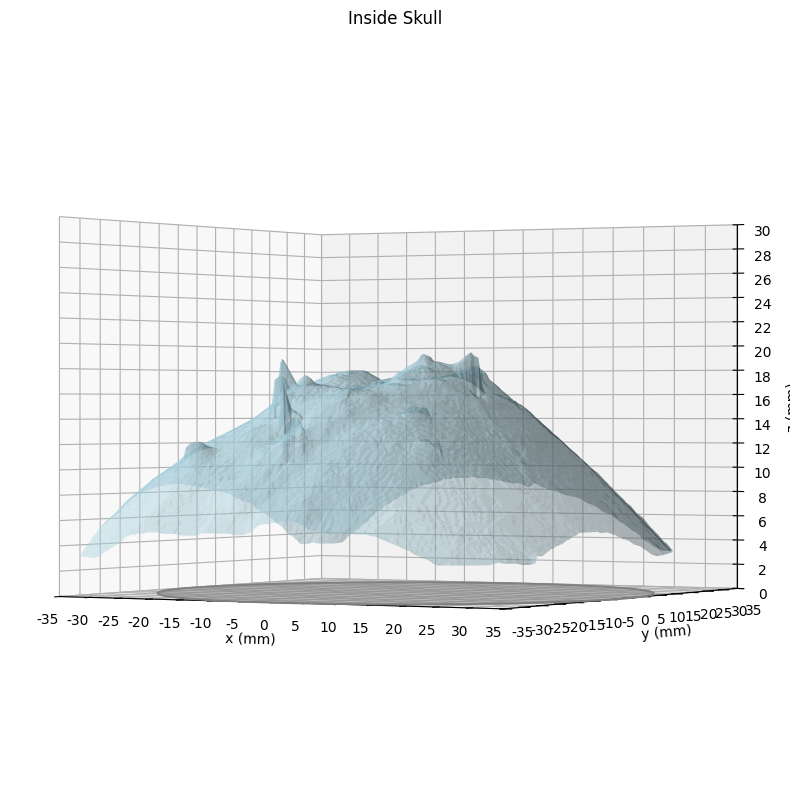

In [49]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert lists to numpy arrays for plotting
X = np.array(x_coords)
Y = np.array(y_coords)
Z = np.array(inner_bone_value)

threshold = 30
x_min, x_max = 32, 96   # example x boundaries
y_min, y_max = 32, 96   # example y boundaries
keep_mask = (Z > threshold) | (
    ((X >= x_min) & (X <= x_max)) &
    ((Y >= y_min) & (Y <= y_max))
)

X = X[keep_mask]
Y = Y[keep_mask]
Z = Z[keep_mask]



surf = ax.plot_trisurf(X, Y, Z, color='lightblue', edgecolor='none', alpha=0.5, linewidth=0, antialiased=True, shade=True)

theta = np.linspace(0, 2 * np.pi, 200)
radius = dim_xy / 2
circle_x = dim_xy / 2 + radius * np.cos(theta)
circle_y = dim_xy / 2 + radius * np.sin(theta)
circle_z = np.zeros_like(circle_x)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
verts = [list(zip(circle_x, circle_y, circle_z))]
circle = Poly3DCollection(verts, color='gray', alpha=0.5)
ax.add_collection3d(circle)
ax.plot(circle_x, circle_y, circle_z, color='gray', linewidth=1)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')
ax.set_ylim(0, dim_xy)
ax.set_xticks(np.linspace(0, dim_xy, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0, dim_xy, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0, dim_xy)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

# Rotate the camera to a horizontal (top-down) view
ax.view_init(elev=0, azim=300)
ax.set_title('Inside Skull')


surface_heights = np.zeros((13, 13))

interp = LinearNDInterpolator(list(zip(X, Y)), Z)

for i in range(1, 14):
    for j in range(1, 14):
        current_total_height = 0
        current_count = 0
        for k in range(10):
            for l in range(10):
                intersection_z = interp((i * 10 + k, j * 10 + l))
                if not np.isnan(intersection_z):
                    current_total_height += intersection_z
                    current_count += 1
        if current_count > 0:
            surface_heights[i-1, j-1] = current_total_height / current_count
        else:
            surface_heights[i-1, j-1] = np.nan

plt.show()

In [102]:
import pandas as pd

# Save surface_heights as csv
x_vals = np.linspace(-30, 30, 13)
y_vals = np.linspace(-30, 30, 13)
df_surface_heights = pd.DataFrame(surface_heights, index=y_vals, columns=x_vals)
df_surface_heights.to_csv('surface_heights.csv')


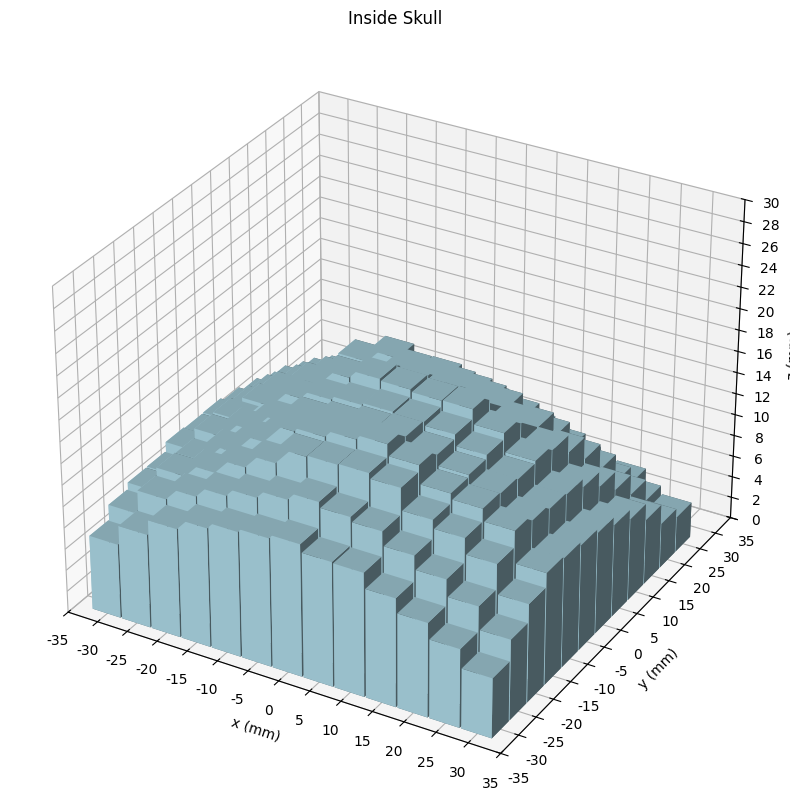

In [62]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

_x = np.arange(1, 14)
_y = np.arange(1, 14)
_xx, _yy = np.meshgrid(_x, _y)
x_flat = _xx.ravel()
y_flat = _yy.ravel()
z_flat = np.zeros_like(x_flat)
dz_flat = surface_heights.ravel()

# Setup bar3d parameters: bar size
dx = dy = 0.95 * np.ones_like(z_flat)  # almost fill the grid

# Optional: mask out NaN surface heights
nan_mask = ~np.isnan(dz_flat)

ax.bar3d(
    x_flat[nan_mask], 
    y_flat[nan_mask], 
    z_flat[nan_mask], 
    dx[nan_mask], 
    dy[nan_mask], 
    dz_flat[nan_mask],
    color='lightblue',
    alpha=1,
    zsort='average'
)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')
ax.set_ylim(0.5, 14.5)
ax.set_xticks(np.linspace(0.5, 14.5, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0.5, 14.5, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0.5, 14.5)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

# Rotate the camera to a horizontal (top-down) view
ax.view_init(elev=30, azim=300)
ax.set_title('Inside Skull')

plt.show()

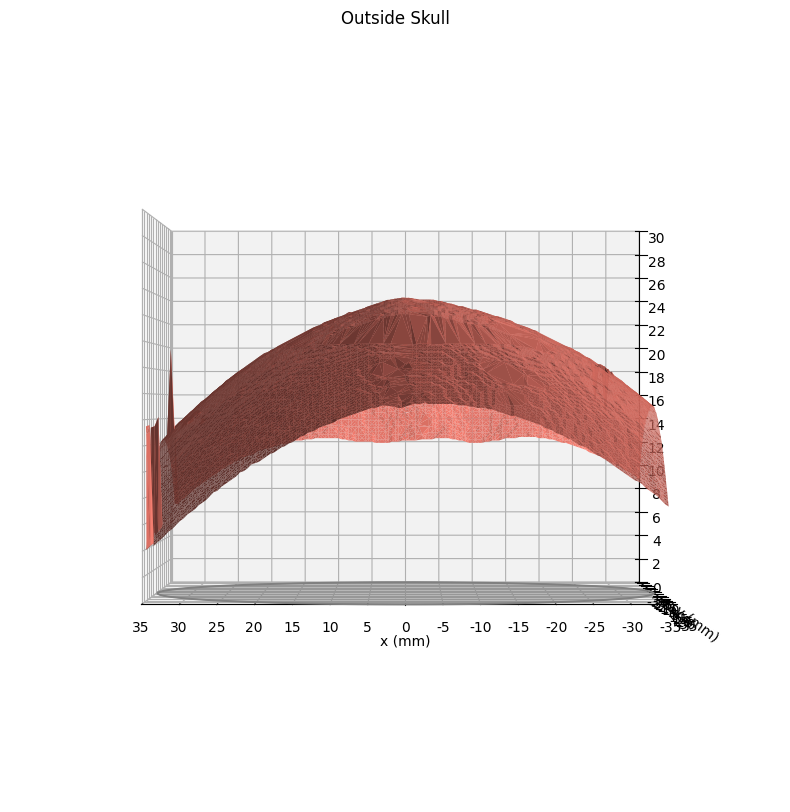

In [103]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert lists to numpy arrays for plotting
import numpy as np
X = np.array(x_coords)
Y = np.array(y_coords)
Z = np.array(outer_bone_value)
nonzero_mask = Z < 250
X = X[nonzero_mask]
Y = Y[nonzero_mask]
Z = Z[nonzero_mask]

# Remove values above threshold (e.g. 200) if outside a certain x and y range
threshold = 200
x_min, x_max = 32, 96   # example x boundaries
y_min, y_max = 32, 96   # example y boundaries

# Keep points if:
#  - Z is below threshold
#  - or if inside the xy range
keep_mask = (Z < threshold) | (
    ((X >= x_min) & (X <= x_max)) &
    ((Y >= y_min) & (Y <= y_max))
)

X = X[keep_mask]
Y = Y[keep_mask]
Z = Z[keep_mask]




# Plot surface, but as we have scattered points, use plot_trisurf for 3d surface
surf = ax.plot_trisurf(X, Y, Z, color='salmon', edgecolor='none', alpha=1, linewidth=0, antialiased=True, shade=True)

theta = np.linspace(0, 2 * np.pi, 200)
radius = dim_xy / 2
circle_x = dim_xy / 2 + radius * np.cos(theta)
circle_y = dim_xy / 2 + radius * np.sin(theta)
circle_z = np.zeros_like(circle_x)
verts = [list(zip(circle_x, circle_y, circle_z))]
circle = Poly3DCollection(verts, color='gray', alpha=0.5)
ax.add_collection3d(circle)
ax.plot(circle_x, circle_y, circle_z, color='gray', linewidth=1)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_ylim(0, dim_xy)
ax.set_xticks(np.linspace(0, dim_xy, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0, dim_xy, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0, dim_xy)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])
ax.view_init(elev=0, azim=90)
ax.set_title('Outside Skull')

surface_heights = np.zeros((13, 13))

interp = LinearNDInterpolator(list(zip(X, Y)), Z)

for i in range(1, 14):
    for j in range(1, 14):
        current_total_height = 0
        current_count = 0
        for k in range(10):
            for l in range(10):
                intersection_z = interp((i * 10 + k, j * 10 + l))
                if not np.isnan(intersection_z):
                    current_total_height += intersection_z
                    current_count += 1
        if current_count > 0:
            surface_heights[i-1, j-1] = current_total_height / current_count
        else:
            surface_heights[i-1, j-1] = np.nan

plt.show()

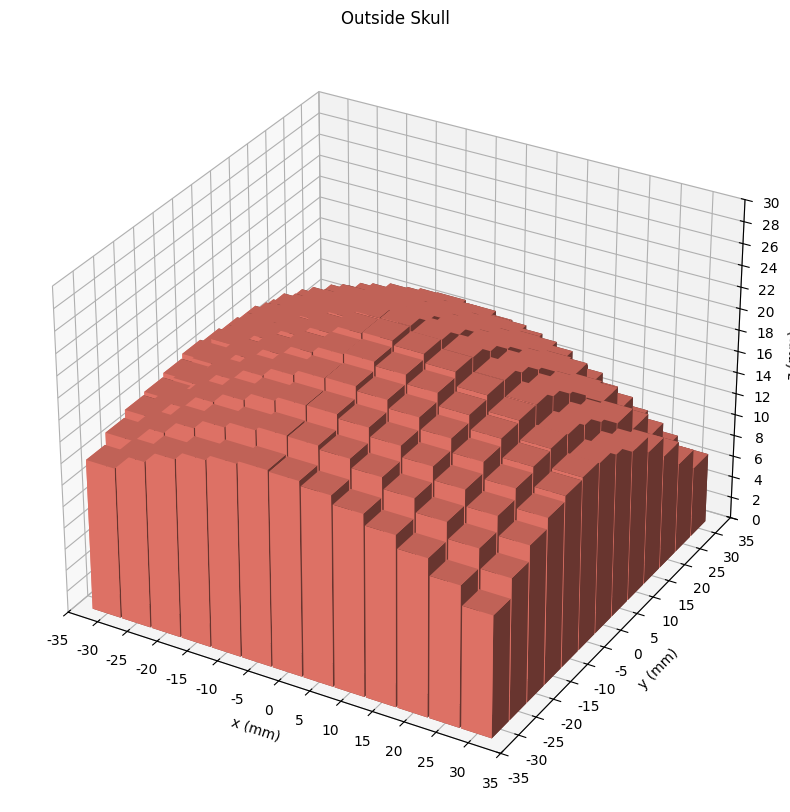

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

_x = np.arange(1, 14)
_y = np.arange(1, 14)
_xx, _yy = np.meshgrid(_x, _y)
x_flat = _xx.ravel()
y_flat = _yy.ravel()
z_flat = np.zeros_like(x_flat)
dz_flat = surface_heights.ravel()

# Setup bar3d parameters: bar size
dx = dy = 0.95 * np.ones_like(z_flat)  # almost fill the grid

# Optional: mask out NaN surface heights
nan_mask = ~np.isnan(dz_flat)

ax.bar3d(
    x_flat[nan_mask], 
    y_flat[nan_mask], 
    z_flat[nan_mask], 
    dx[nan_mask], 
    dy[nan_mask], 
    dz_flat[nan_mask],
    color='salmon',
    alpha=1,
    zsort='average'
)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')
ax.set_ylim(0.5, 14.5)
ax.set_xticks(np.linspace(0.5, 14.5, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0.5, 14.5, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0.5, 14.5)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

# Rotate the camera to a horizontal (top-down) view
ax.view_init(elev=30, azim=300)
ax.set_title('Outside Skull')

plt.show()

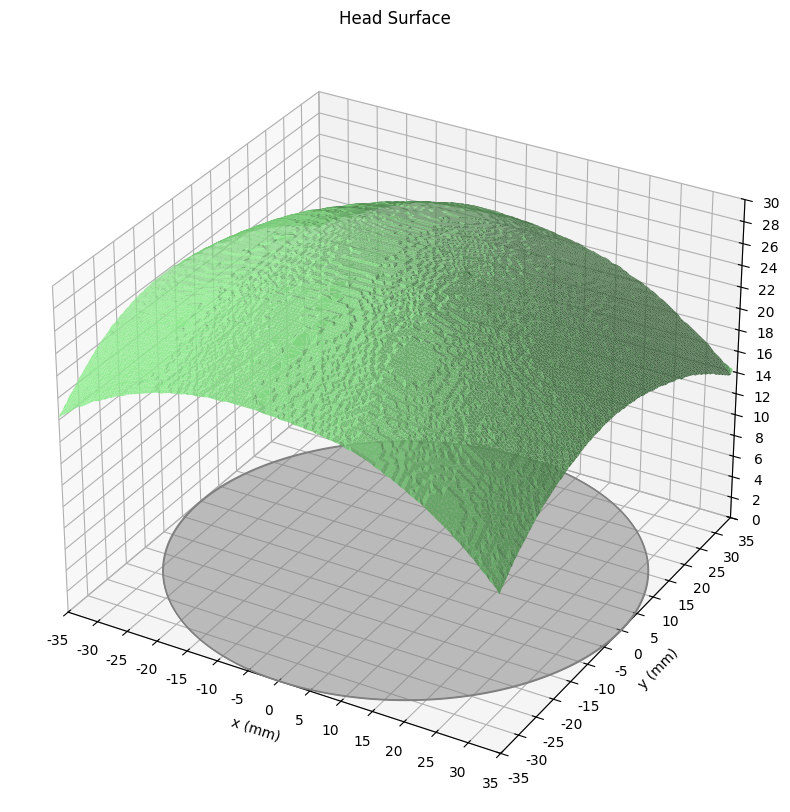

In [101]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert lists to numpy arrays for plotting
import numpy as np
X = np.array(x_coords)
Y = np.array(y_coords)
Z = np.array(head_value)

# Plot surface, but as we have scattered points, use plot_trisurf for 3d surface
surf = ax.plot_trisurf(X, Y, Z, color='lightgreen', edgecolor='none', alpha=1, linewidth=0, antialiased=True, shade=True)

theta = np.linspace(0, 2 * np.pi, 200)
radius = dim_xy / 2
circle_x = dim_xy / 2 + radius * np.cos(theta)
circle_y = dim_xy / 2 + radius * np.sin(theta)
circle_z = np.zeros_like(circle_x)
verts = [list(zip(circle_x, circle_y, circle_z))]
circle = Poly3DCollection(verts, color='gray', alpha=0.5)
ax.add_collection3d(circle)
ax.plot(circle_x, circle_y, circle_z, color='gray', linewidth=1)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_ylim(0, dim_xy)
ax.set_xticks(np.linspace(0, dim_xy, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0, dim_xy, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0, dim_xy)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])
ax.set_title('Head Surface')

surface_heights = np.zeros((13, 13))

interp = LinearNDInterpolator(list(zip(X, Y)), Z)

for i in range(1, 14):
    for j in range(1, 14):
        current_total_height = 0
        current_count = 0
        for k in range(10):
            for l in range(10):
                intersection_z = interp((i * 10 + k, j * 10 + l))
                if not np.isnan(intersection_z):
                    current_total_height += intersection_z
                    current_count += 1
        if current_count > 0:
            surface_heights[i-1, j-1] = current_total_height / current_count
        else:
            surface_heights[i-1, j-1] = np.nan
plt.show()

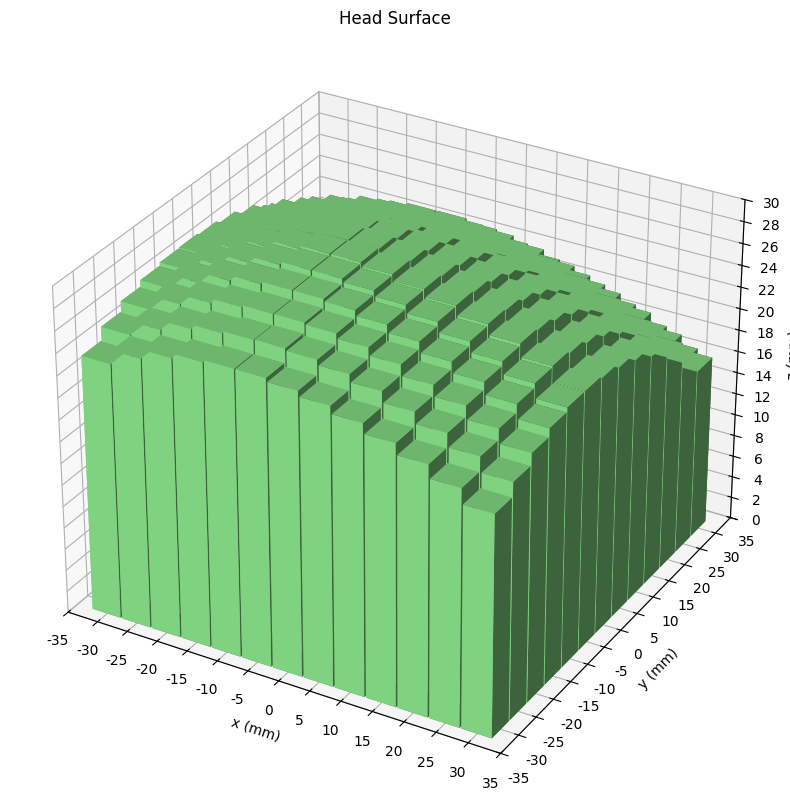

In [72]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

_x = np.arange(1, 14)
_y = np.arange(1, 14)
_xx, _yy = np.meshgrid(_x, _y)
x_flat = _xx.ravel()
y_flat = _yy.ravel()
z_flat = np.zeros_like(x_flat)
dz_flat = surface_heights.ravel()

# Setup bar3d parameters: bar size
dx = dy = 0.95 * np.ones_like(z_flat)  # almost fill the grid

# Optional: mask out NaN surface heights
nan_mask = ~np.isnan(dz_flat)

ax.bar3d(
    x_flat[nan_mask], 
    y_flat[nan_mask], 
    z_flat[nan_mask], 
    dx[nan_mask], 
    dy[nan_mask], 
    dz_flat[nan_mask],
    color='lightgreen',
    alpha=1,
    zsort='average'
)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')
ax.set_ylim(0.5, 14.5)
ax.set_xticks(np.linspace(0.5, 14.5, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0.5, 14.5, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_xlim(0.5, 14.5)

ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

# Rotate the camera to a horizontal (top-down) view
ax.view_init(elev=30, azim=300)
ax.set_title('Head Surface')

plt.show()

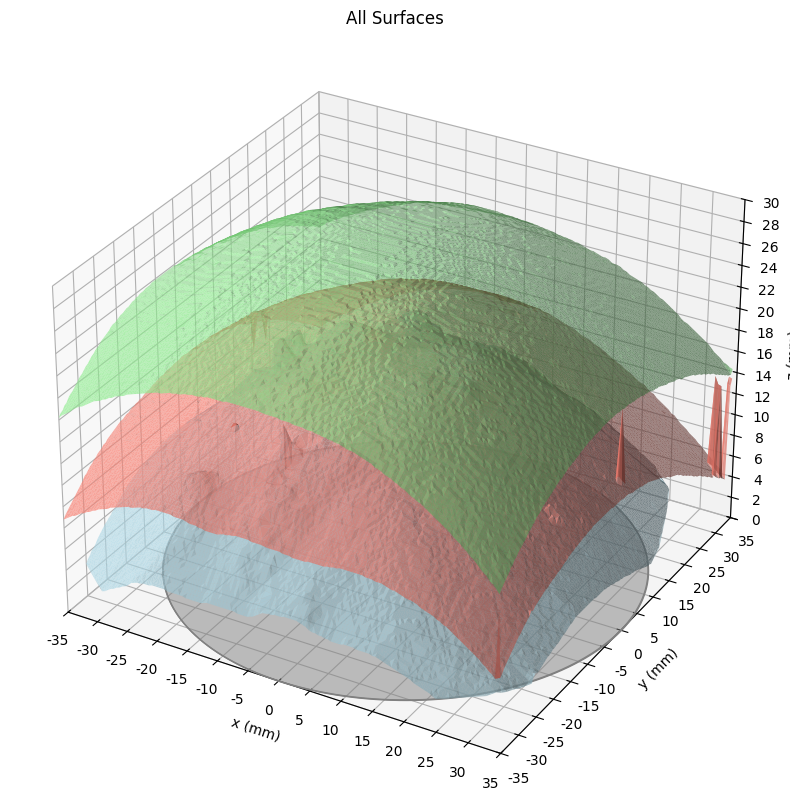

In [44]:
# Combine all three previous 3D surfaces into one plot.
# Assume the coordinates are: (x_coords, y_coords, head_value), (x_coords2, y_coords2, head_value2), (x_coords3, y_coords3, head_value3)
# If your variables differ, adjust accordingly.

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert to numpy arrays for each surface
X1 = np.array(x_coords)
Y1 = np.array(y_coords)
Z1 = np.array(inner_bone_value)

threshold = 30
x_min, x_max = 32, 96   # example x boundaries
y_min, y_max = 32, 96   # example y boundaries
keep_mask = (Z1 > threshold) | (
    ((X1 >= x_min) & (X1 <= x_max)) &
    ((Y1 >= y_min) & (Y1 <= y_max))
)
X1 = X1[keep_mask]
Y1 = Y1[keep_mask]
Z1 = Z1[keep_mask]

X2 = np.array(x_coords)
Y2 = np.array(y_coords)
Z2 = np.array(outer_bone_value)
nonzero_mask = Z2 < 250
X2 = X2[nonzero_mask]
Y2 = Y2[nonzero_mask]
Z2 = Z2[nonzero_mask]

# Remove values above threshold (e.g. 200) if outside a certain x and y range
threshold = 200
x_min, x_max = 32, 96   # example x boundaries
y_min, y_max = 32, 96   # example y boundaries

# Keep points if:
#  - Z2 is below threshold
#  - or if inside the xy range
keep_mask = (Z2 < threshold) | (
    ((X2 >= x_min) & (X2 <= x_max)) &
    ((Y2 >= y_min) & (Y2 <= y_max))
)

X2 = X2[keep_mask]
Y2 = Y2[keep_mask]
Z2 = Z2[keep_mask]



X3 = np.array(x_coords)
Y3 = np.array(y_coords)
Z3 = np.array(head_value)

# Plot all three surfaces using plot_trisurf (scattered points)
ax.plot_trisurf(X1, Y1, Z1, color='lightblue', edgecolor='none', alpha=0.7, linewidth=0, antialiased=True, shade=True, label="Surface 1")
ax.plot_trisurf(X2, Y2, Z2, color='salmon', edgecolor='none', alpha=0.7, linewidth=0, antialiased=True, shade=True, label="Surface 2")
ax.plot_trisurf(X3, Y3, Z3, color='lightgreen', edgecolor='none', alpha=0.7, linewidth=0, antialiased=True, shade=True, label="Surface 3")

# Optionally add the same reference circle as before:
theta = np.linspace(0, 2 * np.pi, 200)
radius = dim_xy / 2
circle_x = dim_xy / 2 + radius * np.cos(theta)
circle_y = dim_xy / 2 + radius * np.sin(theta)
circle_z = np.zeros_like(circle_x)
verts = [list(zip(circle_x, circle_y, circle_z))]
circle = Poly3DCollection(verts, color='gray', alpha=0.5)
ax.add_collection3d(circle)
ax.plot(circle_x, circle_y, circle_z, color='gray', linewidth=1)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')
ax.set_ylim(0, dim_xy)
ax.set_xlim(0, dim_xy)
ax.set_xticks(np.linspace(0, dim_xy, 15))
ax.set_xticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_yticks(np.linspace(0, dim_xy, 15))
ax.set_yticklabels([-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35])
ax.set_zlim(0, 300)
ax.set_zticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
ax.set_zticklabels([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])
# No 'label' argument for trisurf, so use a proxy for legend if needed:

ax.set_title('All Surfaces')
ax.view_init(elev=30, azim=300)
plt.show()

In [ ]:
inner_bone_depth = np.zeroes((13, 13))
outer_bone_depth = np.zeroes((13, 13))
head_depth = np.zeroes((13, 13))

for i in range(1, 14):
    for j in range(1, 14):
        X1 = np.array(x_coords)
        Y1 = np.array(y_coords)
        Z1 = np.array(inner_bone_value)

        mask = (
            (np.array(x_coords) > i * 10 - 5) & (np.array(x_coords) < i * 10 + 5) &
            (np.array(y_coords) > j * 10 - 5) & (np.array(y_coords) < j * 10 + 5)
        )
        X1 = np.array(x_coords)[mask]
        Y1 = np.array(y_coords)[mask]
        Z1 = np.array(inner_bone_value)[mask]
        inner_bone_depth[i-1, j-1] = Z1.mean()
        Z2 = np.array(outer_bone_value)[mask]
        outer_bone_depth[i-1, j-1] = Z2.mean()
        Z3 = np.array(head_value)[mask]